# Using the Stability API
Shows how to use the stablility API to generate and modify images easily.

Treat this notebook as a playground. A generator enables you to render and try out different things, bounded only by your imagination. Take this after the class and try creating different kinds of content to your heart's desire.

# Getting started checklist:


Start by signing up to https://platform.stability.ai/ and making an account there.

Once you have an account, get your API key through this link: https://platform.stability.ai/account/keys


Then, go to https://platform.stability.ai/account/credits and purchase 5USD worth of credits. It will give you 500 credits


Finally, paste your API key on this cell, so you can run all of the examples in this notebook



In [ ]:
from io import BytesIO
import IPython
import json
import os
from PIL import Image
import requests
import getpass
import time
#from google.colab import output
from dotenv import load_dotenv
from torchvision.utils import save_image

load_dotenv()
api_key = os.getenv('PLATFORM_STABILITY_API')
API_KEY = api_key
headers={"authorization": API_KEY,
        "accept": "image/*"}

HOME_DIR = f"{os.environ['HOME']}/Documents/GitHub/Generative-AI"
result_path = f"{HOME_DIR}/results/stability_api"

import sys
sys.path += [result_path]

# Inpainting Tool for the following sections

For the following sections, you will use this online tool to make masks. Save the masks locally to your google colab as **INPAINTING_MASK.png**


Link: https://huggingface.co/spaces/stevhliu/inpaint-mask-maker


# Inpainting and outpainting


We can similarly use the stability API to inpaint and outpaint stuff.

While in class, we explained the technical differences between inpainting, outpainting and erasing,
Stability has done a lot of that legwork for us, defining each of those functionalities already
as different API routes.

You can read more about their parameters here: https://platform.stability.ai/docs/api-reference#tag/Edit/paths/~1v2beta~1stable-image~1edit~1search-and-replace/post

**Now, take this image and save it to your local colab notebook** Name it "border_collie_base.jpeg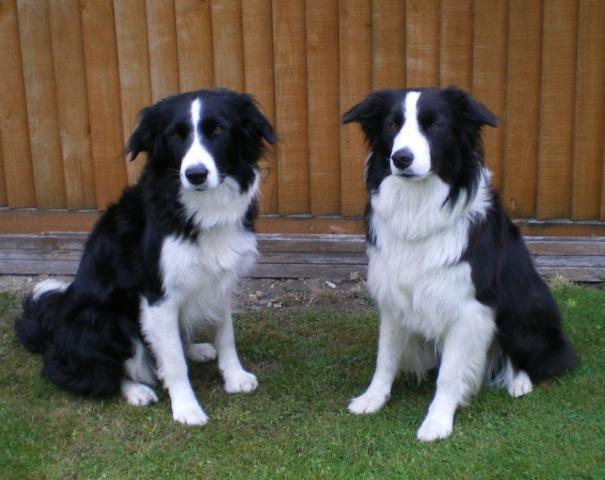"

** Now, click here on the left side, and upload the image here**

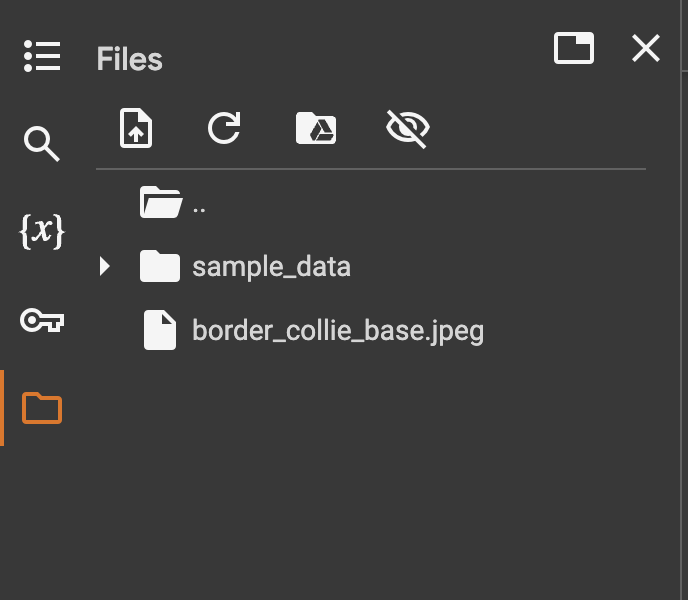

In [ ]:
# First, let's define different functions to create payloads for the different API routes.
# The way you call them is pretty similar:

# Inpainting: Similar to the original request for stablecore, but needs an image
# and a mask, to be inpainted over

# Erasing: Same as inpainting.
BASE_STABILITY_URL = "https://api.stability.ai/" #"https://huggingface.co/stabilityai/stable-diffusion-xl-base-1.0/"

# Search and replace: Stablecore request, also takes in a search_prompt, that will find the content
# you're looking for and replace it
API_URLS = {
    "inpaint":BASE_STABILITY_URL + "v2beta/stable-image/edit/inpaint",
    "erase":BASE_STABILITY_URL + "v2beta/stable-image/edit/erase",
    "search_and_replace": BASE_STABILITY_URL + "v2beta/stable-image/edit/search-and-replace",
    "control_sketch": BASE_STABILITY_URL + "v2beta/stable-image/control/sketch",
    "control_structure": BASE_STABILITY_URL + "v2beta/stable-image/control/structure",
    "upscale_creative": BASE_STABILITY_URL + "v2beta/stable-image/upscale/creative"
}


def make_inpainting_request(prompt,image, mask, * , negative_prompt=None, grow_mask=None):
    fields_in_request = [{"prompt":prompt}]
    if negative_prompt:
      fields_in_request.append({"negative_prompt":negative_prompt})
    if grow_mask:
      fields_in_request.append({"grow_mask":grow_mask})
    request_data = {}
    for field in fields_in_request:
        request_data.update(field)

    # For all of those API routes, the image is provided through the "files" parameter
    # So is the mask
    response = requests.post(
        API_URLS["inpaint"],
        headers=headers,
        files={"image": open(image,"rb"),"mask":open(mask, "rb")},
        data=request_data,
    )
    return response

def make_erase_request(image, mask, *, grow_mask=None):
    fields_in_request = {}
    if grow_mask:
      fields_in_request.append({"grow_mask":grow_mask})
    request_data = {}
    for field in fields_in_request:
        request_data.update(field)

    response = requests.post(
        API_URLS["erase"],
        headers=headers,
        files={"image": open(image,"rb"), "mask":open(mask, "rb")},
        data=request_data,
    )
    return response

def make_search_and_replace_request(prompt, image,search_prompt, *, negative_prompt=None):
    fields_in_request = [{"prompt":prompt,"search_prompt":search_prompt}]
    if negative_prompt:
      fields_in_request.append({"negative_prompt":negative_prompt})
    request_data = {}
    for field in fields_in_request:
        request_data.update(field)

    response = requests.post(
        API_URLS["search_and_replace"],
        headers=headers,
        files={"image": open(image,"rb")},
        data=request_data,
    )
    return response

## Using the erase endpoint

First, let's use the erase endpoint to remove the border collie in the left from the picture.

Scroll up in this class notebook and use the inpainting tool to create a mask
around the border collie in the left. Save the mask as INPAINTING_MASK.png in the same place you saved the border collie images

In [ ]:
import base64
DOGGO_IMAGE = f"{result_path}/border_collie_base.jpeg"
INPAINTING_MASK = f"{result_path}/INPAINTING_MASK.png"
# And read the image as a bytestring
def read_image_as_base64(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")


In [ ]:
# Now, we call the erase API.
erase_response =  make_erase_request(image=DOGGO_IMAGE, mask=INPAINTING_MASK)

image_stream = BytesIO(erase_response.content)
image_object = Image.open(image_stream)
image_object.save(f"{result_path}/erasing_doggo.png")

In [ ]:
# And we can visualize them
IPython.display.Image(f"{result_path}/erasing_doggo.png")


## Using the inpainting endpoint

Now, let's use the inpainting endpoint to modify the same image from before.

Except, this time, instead of replacing the dog on the left, we will replace it with
a grizzly bear cub


In [ ]:
inpainting_prompt = "A cute and fluffy grizzly bear cub, sitting down and panting playfully"

In [ ]:
inpainting_response = make_inpainting_request(prompt=inpainting_prompt, image=DOGGO_IMAGE, mask=INPAINTING_MASK)

image_stream = BytesIO(inpainting_response.content)
image_object = Image.open(image_stream)
image_object.save(f"{result_path}/inpainting_a_grizzly_cub.png")


In [ ]:
IPython.display.Image(f"{result_path}/inpainting_a_grizzly_cub.png")

## Using the Search and Replace endpoint

Now, let's take our image with the border collie and the grizzly bear and replace the fence in the back with something cooler. What about we make it a wild forest?

In [ ]:
CUB_AND_DOGGO_IMAGE = f"{result_path}/inpainting_a_grizzly_cub.png"
search_prompt = "Wooden fence"
replace_prompt = "A beautiful and magical forest, enchanted, portland oregon"
search_and_replace_response = make_search_and_replace_request(prompt=replace_prompt, image=CUB_AND_DOGGO_IMAGE, search_prompt=search_prompt)

image_stream = BytesIO(search_and_replace_response.content)
image_object = Image.open(image_stream)
image_object.save(f"{result_path}/doggo_and_cub_in_forest.png")


In [ ]:
IPython.display.Image(f"{result_path}/doggo_and_cub_in_forest.png")

### Bonus: Upscaling our forest critters


Diffusion models can also creatively upscale images

In [ ]:
# The body of the request should include:

# image
# prompt
# The body may optionally include:

# seed
# negative_prompt
# output_format
# creativity
# Note: for more detail

def make_creative_upscale_request(prompt, image, *,negative_prompt=None, creativity=None):
    fields_in_request = [{"prompt":prompt,"search_prompt":search_prompt}]
    if negative_prompt:
      fields_in_request.append({"negative_prompt":negative_prompt})
    request_data = {}
    for field in fields_in_request:
        request_data.update(field)

    response = requests.post(
        API_URLS["upscale_creative"],
        headers=headers,
        files={"image": open(image,"rb")},
        data=request_data,
    )
    return response




In [ ]:
DOGGO_AND_CUB_IN_FOREST_IMAGE = f"{result_path}/doggo_and_cub_in_forest.png"
creative_prompt = "A grizzly bear cub and a border collie in a magical, ethereal forest. They are surrounded by fae and fairies. The image evokes a sense of adventure and tranquility."
upscale_response = make_creative_upscale_request(prompt=creative_prompt, image=DOGGO_AND_CUB_IN_FOREST_IMAGE,negative_prompt="adult, old", creativity=0.35)


In [ ]:
# Upscale is expensive(25 credits) and takes a while, so we need to fetch the ID for this request
# and poll later to see if it's complete
job_id = upscale_response.json()["id"]
print(upscale_response.json())

In [ ]:
# Now, let's fetch our image. 200 means it's done, 202 means it's still rendering
get_upscaled_image_url = f"https://api.stability.ai/v2beta/stable-image/upscale/creative/result/{job_id}"
upscaled_image_response = requests.get(get_upscaled_image_url,headers=headers)
print(upscaled_image_response)

In [ ]:
# Save and display the image
image_stream = BytesIO(upscaled_image_response.content)
image_object = Image.open(image_stream)
image_object.save(f"{result_path}/upscaled_doggo_and_cub.png")


In [ ]:
IPython.display.Image(f"{result_path}/upscaled_doggo_and_cub.png")

# Controlnet drawing tool for the controlnet section:

For the following sections, you will use this tool on google colab. It lets you draw different sketches that you can submit to the stability API

https://www.autodraw.com/


# Controlling image generation


We can also use a controlnet to control our generation

Here is the API documentation: https://platform.stability.ai/docs/api-reference#tag/Control


Let's start by drawing a sketch using the tool I've made above. And then, make controlnet create a cool image from our drawing

In [ ]:
#The body of the request should include:

# image
# prompt
# The body may optionally include:

# control_strength
# negative_prompt
# seed
# output_format

def make_control_sketch_request(prompt, image,*, control_strength=None, negative_prompt=None, seed=None):
    fields_in_request = [{"prompt":prompt,"search_prompt":search_prompt}]
    if negative_prompt:
      fields_in_request.append({"negative_prompt":negative_prompt})
    if control_strength:
      fields_in_request.append({"control_strength":control_strength})
    if seed:
      fields_in_request.append({"seed":seed})
    request_data = {}
    for field in fields_in_request:
        request_data.update(field)

    response = requests.post(
        API_URLS["control_sketch"],
        headers=headers,
        files={"image": open(image,"rb")},
        data=request_data,
    )
    return response



def make_control_structure_request(prompt, image,*, control_strength=None, negative_prompt=None, seed=None):
    fields_in_request = [{"prompt":prompt,"search_prompt":search_prompt}]
    if negative_prompt:
      fields_in_request.append({"negative_prompt":negative_prompt})
    if control_strength:
      fields_in_request.append({"control_strength":control_strength})
    if seed:
      fields_in_request.append({"seed":seed})
    request_data = {}
    for field in fields_in_request:
        request_data.update(field)

    response = requests.post(
        API_URLS["control_structure"],
        headers=headers,
        files={"image": open(image,"rb")},
        data=request_data,
    )
    return response


## Making content with your sketches


Go to the drawing tool above and draw something. You don't have to be a professional artist, just sketch like you would in a piece of paper. After you're done, save your drawing as MY_SKETCH.png




In [ ]:
# Now, set this prompt to what you want your sketch to turn into
sketch_prompt = "a very simple drawing of a bird"
SKETCH_FILE = f"{result_path}/my_sketch.png"
IPython.display.Image(SKETCH_FILE)

In [ ]:
sketch_response = make_control_sketch_request(prompt=sketch_prompt, image=SKETCH_FILE, control_strength=0.7)

image_stream = BytesIO(sketch_response.content)
image_object = Image.open(image_stream)
image_object.save(f"{result_path}/my_drawing_rendered.png")


In [ ]:
IPython.display.Image(f"{result_path}/my_drawing_rendered.png")

## Finally, let's try to control it with structure!
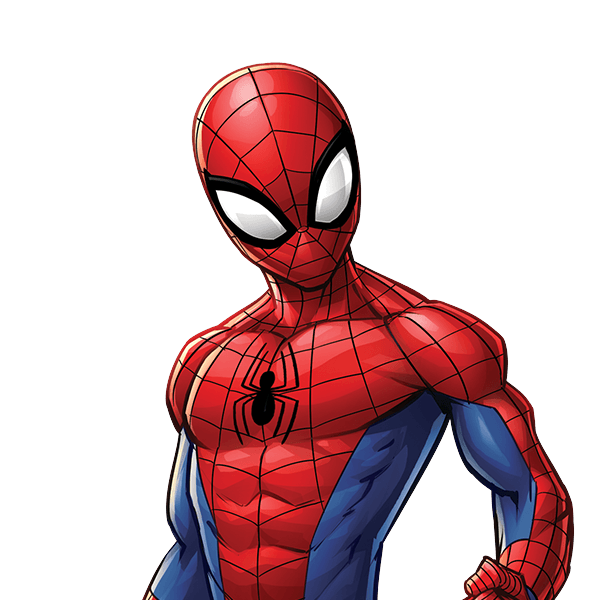
You know the drill! Save the image here as spiderman.png



In [ ]:
spiderman_image_structure = f"{result_path}/spiderman.png"
structure_prompt = "A photo of spiderman in a 50s carnival, with elephants and fire spitters in the background"

structure_response = make_control_structure_request(prompt=structure_prompt, image=spiderman_image_structure, control_strength=0.7)

image_stream = BytesIO(structure_response.content)
image_object = Image.open(image_stream)
image_object.save(f"{result_path}/spiderman_selfie.png")


In [ ]:
IPython.display.Image(f"{result_path}/spiderman_selfie.png")